# 02 — Pipeline walkthrough: from Wigner symbols to an L-edge spectrum

This notebook peels back the `getXAS()` wrapper and exposes the tensors
at each layer of the multitorch pipeline, using the `nid8ct` fixture
throughout so every intermediate is reproducible.

The flow we'll step through:

```
Wigner primitives  →  angular reduced matrix elements
       ↓
COWAN store (.rme_rcg)  +  operator blocks (.rme_rac)  +  recipe (.ban)
       ↓
assemble_and_diagonalize()   →   BanResult (Eg, Ef, T for each triad)
       ↓
read .ban_out  →  BanOutput   (same info, from Fortran)
       ↓
get_sticks()   →   Boltzmann-weighted E, M
       ↓
pseudo_voigt()   →   final broadened spectrum
```

At the end we'll reconstruct the exact `getXAS()` output from the layers
above and show they match to float64 precision.

In [1]:
# Make the notebook runnable from anywhere: chdir to the repo root so
# that relative paths like 'tests/reference_data/...' resolve correctly
# whether you launched jupyter from the repo root or from notebooks/.
import os
from pathlib import Path
_here = Path.cwd()
for _anc in [_here, *_here.parents]:
    if (_anc / "multitorch").is_dir() and (_anc / "tests" / "reference_data").is_dir():
        os.chdir(_anc)
        break
print("working dir:", Path.cwd())

working dir: /Users/afollmer/Follmer_UCD/Follmer_Lab/Code/multiplets/multitorch


## Layer 1 — Wigner primitives

All angular-momentum coupling in the pipeline ultimately bottoms out in
Wigner 3j and 6j symbols. `multitorch.angular.wigner` provides
differentiable, float64 implementations that match the standard
recursions to ~1e-16.

In [2]:
import torch
from multitorch.angular.wigner import wigner3j, wigner6j

# A dipole 3j symbol: < p || C^1 || d >  needs (1, 1, 2; 0, 0, 0)
w3j = wigner3j(1, 1, 2, 0, 0, 0)
print(f"( 1 1 2 ; 0 0 0 ) = {float(w3j):+.12f}")

# Triangle condition check
w3j_bad = wigner3j(1, 1, 4, 0, 0, 0)  # violates triangle inequality
print(f"( 1 1 4 ; 0 0 0 ) = {float(w3j_bad):+.12f}  (should be 0)")

# A sample 6j (appears in angular RME for a 2-shell coupled system)
w6j = wigner6j(2, 1, 1, 1, 2, 2)
print(f"{{ 2 1 1 ; 1 2 2 }} = {float(w6j):+.12f}")

( 1 1 2 ; 0 0 0 ) = +0.365148371670
( 1 1 4 ; 0 0 0 ) = +0.000000000000  (should be 0)
{ 2 1 1 ; 1 2 2 } = +0.152752523165


## Layer 2 — Read the COWAN store and operator blocks

The `.rme_rcg` file is a series of COWAN-format blocks, each a sparse
reduced-matrix-element matrix in an angular-momentum basis. The
`.rme_rac` file is the symmetry-adapted form of the same information.

In [3]:
from pathlib import Path
from multitorch.io.read_rme import read_cowan_store, read_rme_rac_full

REFROOT = Path("tests/reference_data/nid8ct")

cowan_sections = read_cowan_store(str(REFROOT / "nid8ct.rme_rcg"))
print(f"COWAN store: {len(cowan_sections)} sections")
for i, section in enumerate(cowan_sections):
    print(f"  section {i}: {len(section)} matrices")
    for j, mat in enumerate(section[:3]):  # show up to 3 per section
        print(f"    matrix {j+1}: {tuple(mat.shape)}  "
              f"(nonzeros: {int((mat != 0).sum())})")

COWAN store: 4 sections
  section 0: 22 matrices
    matrix 1: (2, 3)  (nonzeros: 3)
    matrix 2: (1, 1)  (nonzeros: 1)
    matrix 3: (1, 3)  (nonzeros: 2)
  section 1: 24 matrices
    matrix 1: (2, 3)  (nonzeros: 3)
    matrix 2: (4, 1)  (nonzeros: 3)
    matrix 3: (4, 3)  (nonzeros: 6)
  section 2: 167 matrices
    matrix 1: (2, 2)  (nonzeros: 2)
    matrix 2: (1, 1)  (nonzeros: 1)
    matrix 3: (3, 3)  (nonzeros: 3)
  section 3: 142 matrices
    matrix 1: (1, 1)  (nonzeros: 1)
    matrix 2: (3, 3)  (nonzeros: 3)
    matrix 3: (4, 4)  (nonzeros: 4)


In [4]:
rac = read_rme_rac_full(str(REFROOT / "nid8ct.rme_rac"))
print(f"RAC file: {len(rac.blocks)} blocks, {len(rac.irreps)} irreps")
# Show a handful of GROUND blocks
for b in rac.blocks[:6]:
    print(f"  {b.kind:7s} {b.bra_sym:4s} {b.geometry:12s} "
          f"bra×ket = {b.n_bra}×{b.n_ket}  (adds: {len(b.add_entries)})")

RAC file: 226 blocks, 40 irreps
  TRANSI  0+   PERP         bra×ket = 9×15  (adds: 11)
  TRANSI  ^0+  PERP         bra×ket = 4×15  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×7  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×7  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×8  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×8  (adds: 13)


## Layer 3 — Assemble and diagonalize the Hamiltonian

`assemble_and_diagonalize()` combines `.rme_rcg`, `.rme_rac`, and `.ban`
into a block-diagonal charge-transfer Hamiltonian, diagonalizes it for
each symmetry triad, and returns eigenvalues, eigenvectors, and
transition matrices. This is the PyTorch equivalent of `ttban_exact.f`.

In [5]:
from multitorch.hamiltonian.assemble import assemble_and_diagonalize

result = assemble_and_diagonalize(
    str(REFROOT / "nid8ct.rme_rcg"),
    str(REFROOT / "nid8ct.rme_rac"),
    str(REFROOT / "nid8ct.ban"),
)

print(f"BanResult with {len(result.triads)} triads")
print()
print(f"{'gs':>4s} {'act':>4s} {'fs':>4s}   {'n_gs':>5s} {'n_fs':>5s}   "
      f"{'Eg.min':>10s} {'Ef.min':>10s}")
for t in result.triads[:6]:
    print(f"{t.gs_sym:>4s} {t.act_sym:>4s} {t.fs_sym:>4s}   "
          f"{t.n_gs:>5d} {t.n_fs:>5d}   "
          f"{float(t.Eg.min()):>+10.4f} {float(t.Ef.min()):>+10.4f}")

BanResult with 13 triads

  gs  act   fs    n_gs  n_fs       Eg.min     Ef.min
  0+   1-   1-      22    30      -2.1905  +852.3005
 ^0+   1-   1-      17    30      -2.1648  +852.3005
  1+   1-   0-      35    14      -3.4506  +852.1860
  1+   1-  ^0-      35    14      -3.4506  +852.1915
  1+   1-   2-      35    16      -3.4506  +852.3445
  1+   1-  ^2-      35    16      -3.4506  +852.1720


Pick one triad and look at the transition matrix directly:

Biggest triad: gs=1+ act=^0- fs=1-  T shape = (35, 30)


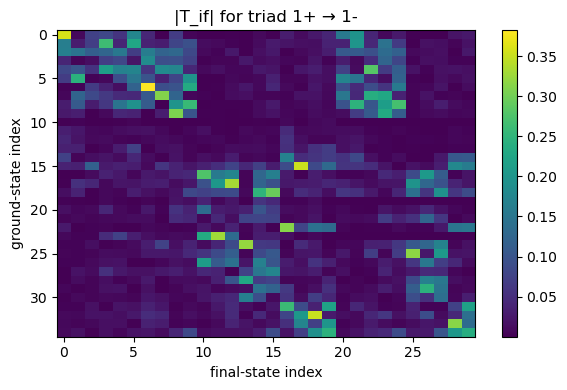

In [6]:
import matplotlib.pyplot as plt

# The largest triad is usually the most informative
biggest = max(result.triads, key=lambda t: t.T.numel())
print(f"Biggest triad: gs={biggest.gs_sym} act={biggest.act_sym} fs={biggest.fs_sym}  "
      f"T shape = {tuple(biggest.T.shape)}")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(biggest.T.abs().detach().numpy(), aspect="auto", cmap="viridis")
ax.set_xlabel("final-state index")
ax.set_ylabel("ground-state index")
ax.set_title(f"|T_if| for triad {biggest.gs_sym} → {biggest.fs_sym}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Layer 4 — Read the Fortran `.ban_out` and compare

To drive the final broadening we use the bootstrap path
(`read_ban_output` → `get_sticks` → `pseudo_voigt`). The Fortran
`.ban_out` file contains the same eigenvalues + transition matrices that
we just computed — let's verify the eigenvalues agree.

In [7]:
from multitorch.io.read_oba import read_ban_output

ban = read_ban_output(str(REFROOT / "nid8ct.ban_out"))
print(f"BanOutput: {len(ban.triad_list)} triads from Fortran .ban_out")

# Line up the first common triad and compare its lowest eigenvalue
py_first = result.triads[0]
# find matching triad in ban by symmetry labels (ban uses ground_sym/final_sym)
fort_match = None
for t in ban.triad_list:
    if (t.ground_sym == py_first.gs_sym and t.op_sym == py_first.act_sym
            and t.final_sym == py_first.fs_sym):
        fort_match = t
        break

if fort_match is not None:
    dE = abs(float(py_first.Eg.min()) - float(fort_match.Eg.min()))
    print(f"First triad {py_first.gs_sym}→{py_first.fs_sym}: "
          f"Eg.min PyTorch = {float(py_first.Eg.min()):+.6f} Ry, "
          f"Fortran = {float(fort_match.Eg.min()):+.6f} Ry, "
          f"|ΔE| = {dE:.2e} Ry")
else:
    print(f"No Fortran triad matches PyTorch first triad "
          f"({py_first.gs_sym}→{py_first.fs_sym})")

BanOutput: 15 triads from Fortran .ban_out
First triad 0+→1-: Eg.min PyTorch = -2.190454 Ry, Fortran = -2.190450 Ry, |ΔE| = 4.45e-06 Ry


## Layer 5 — Boltzmann sticks and broadening

`get_sticks()` collapses all the per-triad transition matrices into a
single 1-D stick spectrum, weighted by a Boltzmann factor on the ground
states. `pseudo_voigt()` then convolves the sticks into a smooth curve.

79 sticks; E range [855.62, 880.01] eV


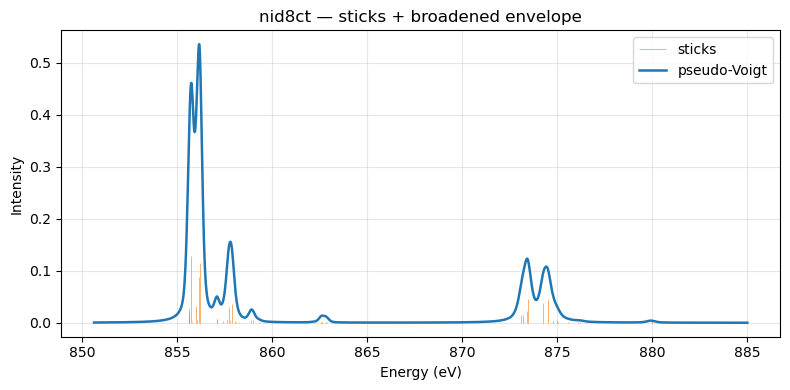

In [8]:
from multitorch.spectrum.sticks import get_sticks
from multitorch.spectrum.broaden import pseudo_voigt

E_sticks, M_sticks, Eg_min = get_sticks(ban, T=80.0, max_gs=1)
print(f"{E_sticks.shape[0]} sticks; "
      f"E range [{float(E_sticks.min()):.2f}, {float(E_sticks.max()):.2f}] eV")

# Build the broadened spectrum on a dense grid
x_grid = torch.linspace(float(E_sticks.min()) - 5.0,
                        float(E_sticks.max()) + 5.0,
                        2000, dtype=torch.float64)
med = 0.5 * (float(E_sticks.min()) + float(E_sticks.max()))
y_grid = pseudo_voigt(
    x_grid, E_sticks, M_sticks,
    fwhm_g=0.2, fwhm_l=0.2, fwhm_l2=0.4,
    med_energy=med, mode="legacy",
)

fig, ax = plt.subplots(figsize=(8, 4))
# stick plot via vlines
ax.vlines(E_sticks.numpy(), 0, M_sticks.numpy(),
          color="C1", lw=0.6, alpha=0.7, label="sticks")
ax.plot(x_grid.numpy(), y_grid.numpy(), "C0", lw=1.8, label="pseudo-Voigt")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Intensity")
ax.set_title("nid8ct — sticks + broadened envelope")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Layer 6 — Closing the loop: does this match `getXAS()`?

`getXAS()` is just a thin wrapper around the parse → sticks → broaden
chain above, so the two should be byte-identical on the same grid.

In [9]:
from multitorch.api.plot import getXAS

x_hi, y_hi = getXAS(str(REFROOT / "nid8ct.ban_out"),
                    T=80.0, beam_fwhm=0.2, gamma1=0.2, gamma2=0.4, nbins=2000)

# getXAS uses the same defaults — check that our manual reconstruction
# matches to floating-point noise
max_abs_err = float((y_hi - y_grid).abs().max())
rel_err = max_abs_err / float(y_hi.abs().max())
print(f"max |getXAS() - manual|       = {max_abs_err:.2e}")
print(f"relative max error            = {rel_err:.2e}")
print(f"matched to float64 precision: {max_abs_err < 1e-10}")

max |getXAS() - manual|       = 0.00e+00
relative max error            = 0.00e+00
matched to float64 precision: True


## Recap

| Layer | Tensor type | Where defined |
|---|---|---|
| Wigner 3j/6j | scalars / tensors | `multitorch.angular.wigner` |
| COWAN store | sparse matrices | `multitorch.io.read_rme` |
| Symmetry blocks | per-block matrices | `multitorch.io.read_rme` |
| Hamiltonian | `BanResult.triads[i].Eg/Ef/T` | `multitorch.hamiltonian.assemble` |
| Sticks | `(E, M)` tensors | `multitorch.spectrum.sticks` |
| Spectrum | `(x, y)` tensors | `multitorch.spectrum.broaden` |

Every layer is pure PyTorch, float64, autograd-compatible. The
`getXAS()` wrapper just calls into Layers 5–6 with the `.ban_out`
bootstrap input; if you want to run Layer 4 yourself (assembling from
raw RMEs), use `assemble_and_diagonalize()` as shown above.